In [2]:
df

organisms,indicator_value,R_G1,p_G1,R_G2,p_G2,R_G3,p_G3
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>
A,0.98,1.00,0.05,0.20,5,0.09,0.02
B,0.98,0.05,NA,0.10,3,0.09,0.04
C,0.98,0.02,0.02,0.07,NA,0.20,0.02



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




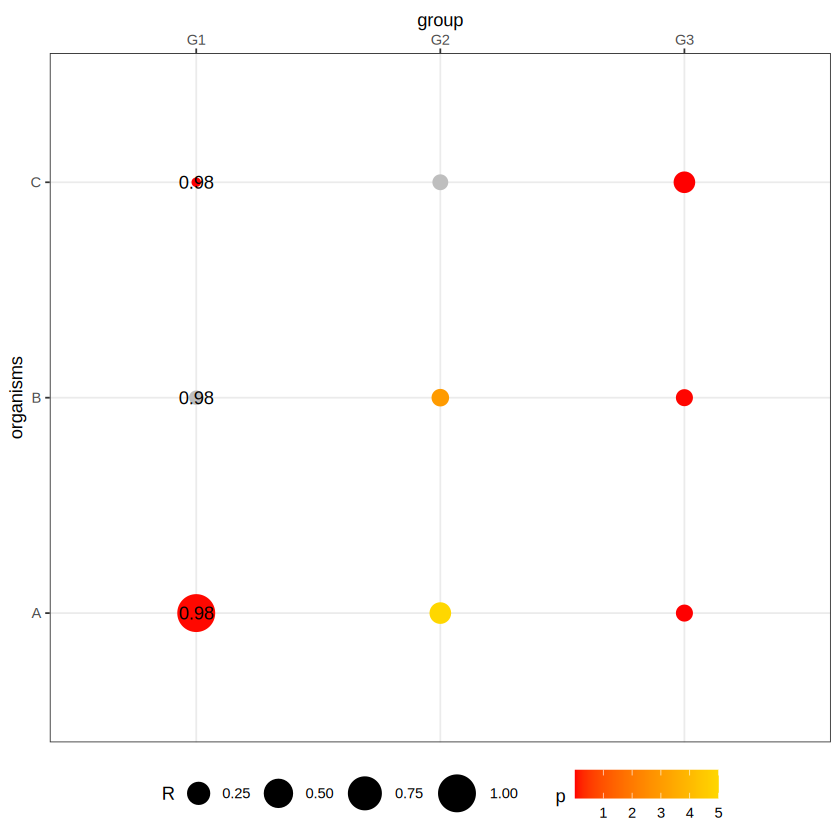

In [2]:
library(ggplot2)
library(tidyr)
library(dplyr)

# Creating the dataframe
df <- structure(list(
  organisms = structure(1:3, .Label = c("A", "B", "C"), class = "factor"), 
  indicator_value = c(0.98, 0.98, 0.98), 
  R_G1 = c(1, 0.05, 0.02), p_G1 = c(0.05, NA, 0.02), 
  R_G2 = c(0.2, 0.1, 0.07), p_G2 = c(5L, 3L, NA), 
  R_G3 = c(0.09, 0.09, 0.2), p_G3 = c(0.02, 0.04, 0.02)
), class = "data.frame", row.names = c(NA, -3L))

# Transforming the data to long format for R and p values separately
df_long <- df %>%
  pivot_longer(cols = -c(organisms, indicator_value), names_to = c(".value", "group"), 
               names_pattern = "(R|p)_(G[0-9]+)") 

# Plot
ggplot(df_long, aes(x = group, y = organisms)) +
  geom_point(aes(size = R, color = p)) +  # Size represents R, color represents p
  geom_text(data = df %>% select(organisms, indicator_value), 
            aes(x = "G1", label = indicator_value), check_overlap = TRUE) +
  scale_color_gradient(low = "red", high = "gold", na.value = "grey") + 
  scale_size(range = c(2, 10)) + 
  scale_x_discrete(position = "top") + 
  theme_bw() + 
  theme(legend.position = "bottom")


In [14]:
df_long

organisms,indicator_value,group,R,p
<fct>,<dbl>,<chr>,<dbl>,<dbl>
A,0.98,G1,1.00,0.05
A,0.98,G2,0.20,5.00
A,0.98,G3,0.09,0.02
B,0.98,G1,0.05,NA
B,0.98,G2,0.10,3.00
B,0.98,G3,0.09,0.04
C,0.98,G1,0.02,0.02
C,0.98,G2,0.07,NA
C,0.98,G3,0.20,0.02


In [15]:
df

edge,cog_decline,P_value_AD,AD_correlation_value
<chr>,<chr>,<dbl>,<dbl>
ATOH8-PEX5,cognwo_demog_slope,0.01445215,-0.27086721
HIC2-ENSG00000234841,cognwo_demog_slope,0.01626779,-0.26628275
HIC2-ENSG00000234841,cognse_demog_slope,0.01750028,-0.26504923
HIC2-ENSG00000234841,cognwo_path_slope,0.02869954,-0.25617055
ATOH8-PEX5,cogng_path_slope,0.04139924,-0.23935579
NEUROD1-PEX5,cognwo_demog_slope,0.03146591,-0.23925023
MTF1-CYLD,cognep_path_slope,0.04257380,-0.23802913
MESP1-ZC3H12D,cognep_demog_slope,0.03246938,-0.23789521
HIC2-ENSG00000234841,cogng_demog_slope,0.03471813,-0.23498193


In [6]:
library(tidyr)
library(dplyr)

# Original dataframe
df <- data.frame(
  edge = c(57867, 62583, 63939),
  cog_decline = c("ATOH8-PEX5", "HIC2-ENSG00000234841", "HIC2-ENSG00000234841"),
  P_value_AD = c(0.014452, 0.016268, 0.017500),
  AD_correlation_value = c(-0.270867, -0.266283, -0.265049),
  group = c("cognwo_demog_slope", "cognwo_demog_slope", "cognse_demog_slope")
)

# Reshaping to make `cog_decline` (now `edge`) as row names
df_wide <- df %>%
  pivot_wider(names_from = group, values_from = c(P_value_AD, AD_correlation_value))

# Renaming column for clarity
colnames(df_wide)[colnames(df_wide) == "cog_decline"] <- "edge"

# Print output
print(df_wide)


# A tibble: 3 × 6
   edge edge                 P_value_AD_cognwo_demog_sl…¹ P_value_AD_cognse_de…²
  <dbl> <chr>                                       <dbl>                  <dbl>
1 57867 ATOH8-PEX5                                 0.0145                NA     
2 62583 HIC2-ENSG00000234841                       0.0163                NA     
3 63939 HIC2-ENSG00000234841                      NA                      0.0175
# ℹ abbreviated names: ¹​P_value_AD_cognwo_demog_slope,
#   ²​P_value_AD_cognse_demog_slope
# ℹ 2 more variables: AD_correlation_value_cognwo_demog_slope <dbl>,
#   AD_correlation_value_cognse_demog_slope <dbl>


In [7]:
df_wide

edge,edge,P_value_AD_cognwo_demog_slope,P_value_AD_cognse_demog_slope,AD_correlation_value_cognwo_demog_slope,AD_correlation_value_cognse_demog_slope
<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
57867,ATOH8-PEX5,0.014452,NA,-0.270867,NA
62583,HIC2-ENSG00000234841,0.016268,NA,-0.266283,NA
63939,HIC2-ENSG00000234841,NA,0.0175,NA,-0.265049


In [8]:
df <- read.csv("../../../data_preprocessed/correlation_output/ad_corr_for_plot.csv")  # Replace with your file path
head(df)

,edge,cog_decline,P_value_AD,AD_correlation_value
,<chr>,<chr>,<dbl>,<dbl>
1,ATOH8-PEX5,cognwo_demog_slope,0.01445215,-0.2708672
2,HIC2-ENSG00000234841,cognwo_demog_slope,0.01626779,-0.2662827
3,HIC2-ENSG00000234841,cognse_demog_slope,0.01750028,-0.2650492
4,HIC2-ENSG00000234841,cognwo_path_slope,0.02869954,-0.2561706
5,ATOH8-PEX5,cogng_path_slope,0.04139924,-0.2393558
6,NEUROD1-PEX5,cognwo_demog_slope,0.03146591,-0.2392502


In [48]:
install.packages("svglite")


Installing package into ‘/home/anwer/R/x86_64-pc-linux-gnu-library/4.3’
(as ‘lib’ is unspecified)



In [42]:
options(repr.plot.width = 11, repr.plot.height =12)

In [49]:
library(ggplot2)
library(dplyr)
p <- ggplot(df, aes(x = edge, y = cog_decline)) +
  geom_point(aes(size = abs(AD_correlation_value), color = P_value_AD)) +  
  scale_color_gradient(low = "red", high = "gold", na.value = "grey") + 
  scale_size(range = c(1, 5)) + 
  scale_x_discrete(position = "bottom") + 
  theme_bw(base_size = 15) + 
  theme(legend.position = "bottom") +
labs(x = "TF-gene", y = "Cognitive Decline", size = "Correlation Strength", color = "P-value")  +
  theme(plot.title = element_text(hjust = 0.5))+ 
 ggtitle("Bubble Plot of TF-Gene vs Cognitive Decline") +
theme(axis.text.x = element_text(angle = 45, hjust = 1))

ggsave("../../../data_preprocessed/grn_analysis_output/plots/TF_Gene_Bubble_Plot.svg", plot = p, width = 10, height = 6, dpi = 300, device = "svg")


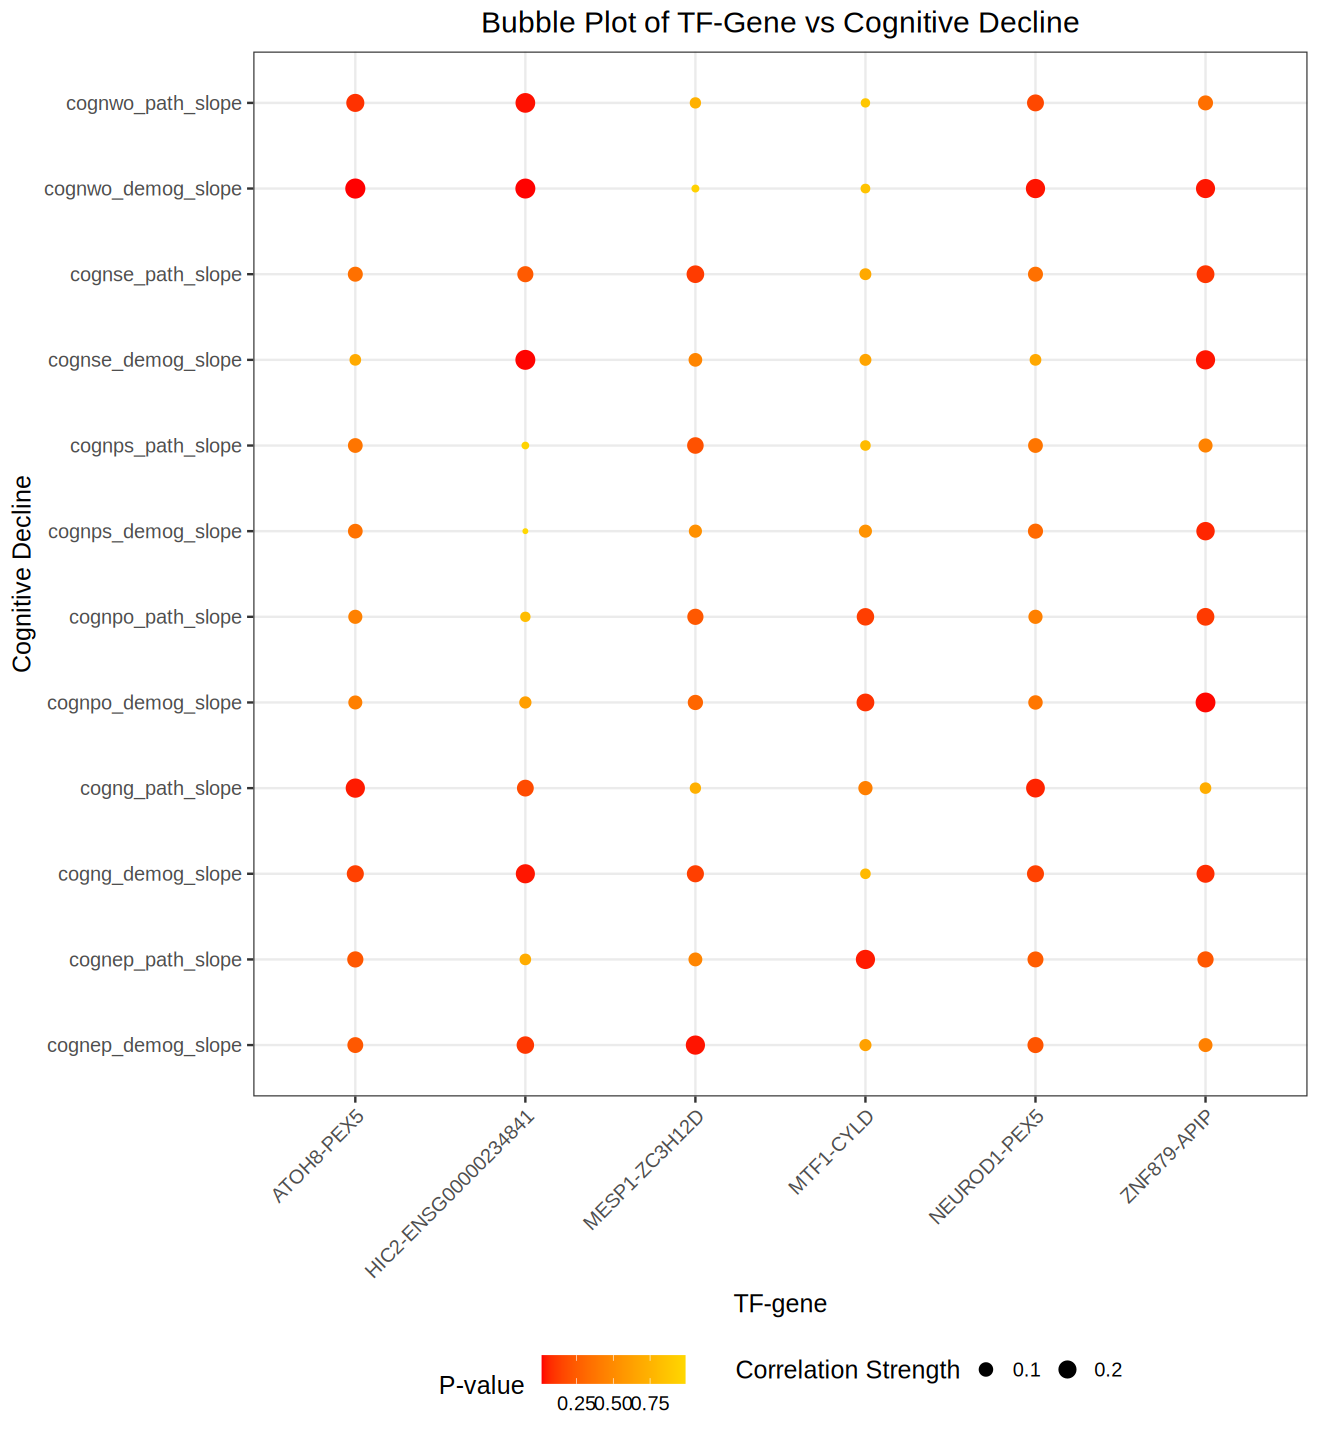

In [50]:
p

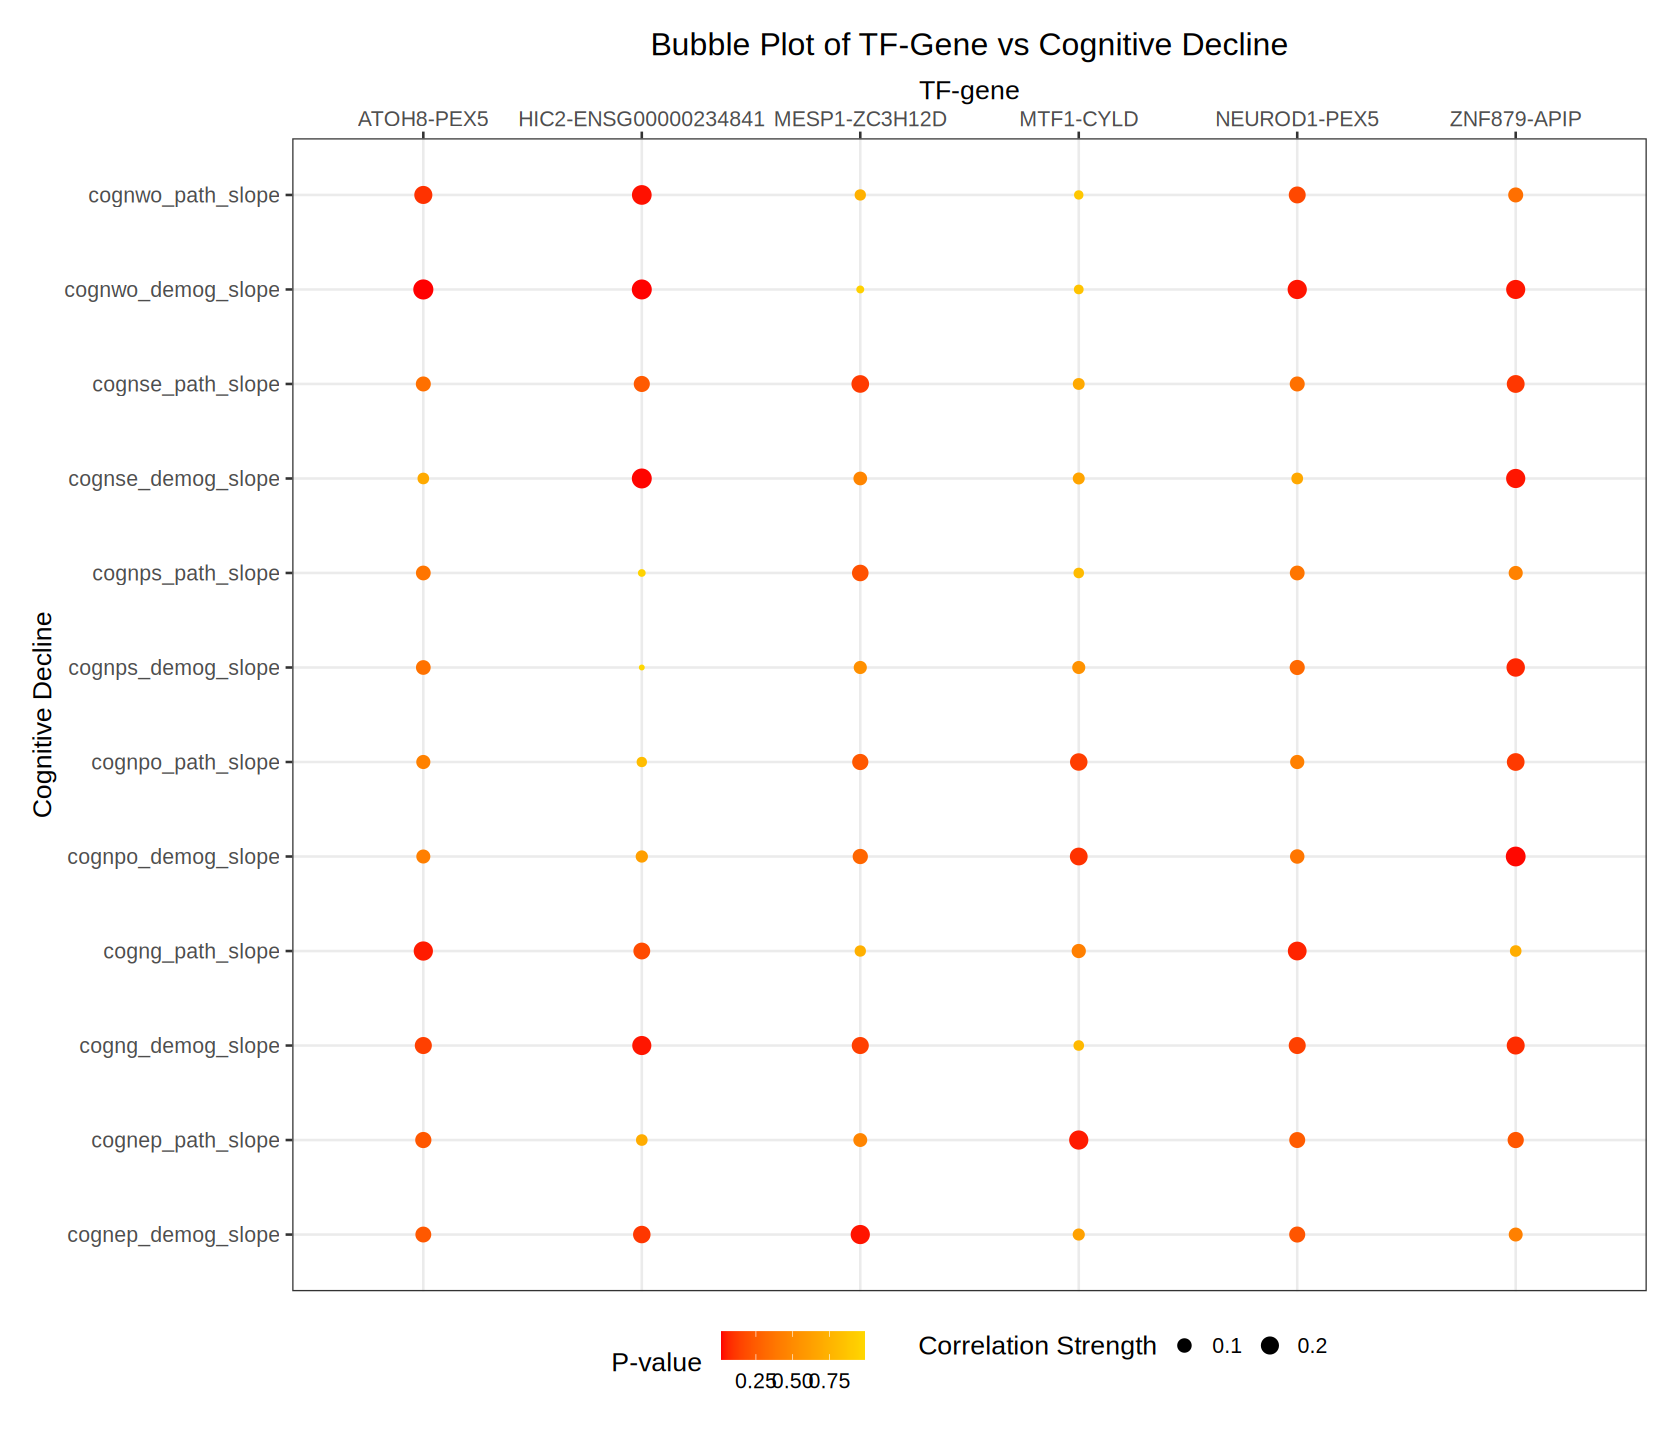

In [39]:
ggplot(df, aes(x = edge, y = cog_decline)) +
  geom_point(aes(size = abs(AD_correlation_value), color = P_value_AD)) +  
  scale_color_gradient(low = "red", high = "gold", na.value = "grey") + 
  scale_size(range = c(1, 5)) +  # Increased bubble size
  scale_x_discrete(position = "top") + 
  theme_bw(base_size = 16) +  # Increase text size for better visibility
  theme(
    legend.position = "bottom",
    plot.margin = margin(20, 20, 20, 20)  # Increase plot margins
  ) +
  labs(x = "TF-gene", y = "Cognitive Decline", size = "Correlation Strength", color = "P-value") +
  theme(plot.title = element_text(hjust = 0.5)) +  # Center the title
  ggtitle("Bubble Plot of TF-Gene vs Cognitive Decline")

In [ ]:
ggsave("TF_Gene_Bubble_Plot.svg", plot = p, width = 10, height = 6, dpi = 300, device = "svg")


In [56]:
colnames(df_wide)

[1] "edge"                                   
 [2] "P_value_AD_cognwo_demog_slope"          
 [3] "P_value_AD_cognse_demog_slope"          
 [4] "P_value_AD_cognwo_path_slope"           
 [5] "P_value_AD_cogng_path_slope"            
 [6] "P_value_AD_cognep_path_slope"           
 [7] "P_value_AD_cognep_demog_slope"          
 [8] "P_value_AD_cogng_demog_slope"           
 [9] "P_value_AD_cognse_path_slope"           
[10] "P_value_AD_cognps_demog_slope"          
[11] "P_value_AD_cognps_path_slope"           
[12] "P_value_AD_cognpo_demog_slope"          
[13] "P_value_AD_cognpo_path_slope"           
[14] "AD_correlation_value_cognwo_demog_slope"
[15] "AD_correlation_value_cognse_demog_slope"
[16] "AD_correlation_value_cognwo_path_slope" 
[17] "AD_correlation_value_cogng_path_slope"  
[18] "AD_correlation_value_cognep_path_slope" 
[19] "AD_correlation_value_cognep_demog_slope"
[20] "AD_correlation_value_cogng_demog_slope" 
[21] "AD_correlation_value_cognse_path_slope" 
[22] "AD_correlation_value_cognps_demog_slope"
[23] "AD_correlation_value_cognps_path_slope" 
[24] "AD_correlation_value_cognpo_demog_slope"
[25] "AD_correlation_value_cognpo_path_slope"

In [62]:
df_wide[, 1:13]

edge,P_value_AD_cognwo_demog_slope,P_value_AD_cognse_demog_slope,P_value_AD_cognwo_path_slope,P_value_AD_cogng_path_slope,P_value_AD_cognep_path_slope,P_value_AD_cognep_demog_slope,P_value_AD_cogng_demog_slope,P_value_AD_cognse_path_slope,P_value_AD_cognps_demog_slope,P_value_AD_cognps_path_slope,P_value_AD_cognpo_demog_slope,P_value_AD_cognpo_path_slope
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ATOH8-PEX5,0.01445215,0.68950956,0.09016700,0.04139924,0.2265441,0.23170214,0.13330044,0.3478118,0.35567417,0.3759294,0.42849541,0.4421241
HIC2-ENSG00000234841,0.01626779,0.01750028,0.02869954,0.17395866,0.7068578,0.10545163,0.03471813,0.2394841,0.98963754,0.9608181,0.62305149,0.8151306
NEUROD1-PEX5,0.03146591,0.68085094,0.16557798,0.05815443,0.2473871,0.21496551,0.13758078,0.3480899,0.31331046,0.3738200,0.38006143,0.4339957
MTF1-CYLD,0.85283183,0.65512525,0.88198695,0.42766981,0.0425738,0.63567211,0.78532153,0.6850526,0.53811943,0.8022713,0.09129004,0.1293478
MESP1-ZC3H12D,0.95117671,0.46492819,0.73462185,0.73247353,0.4650076,0.03246938,0.13245664,0.1177559,0.53094830,0.2006730,0.29458482,0.2292048
ZNF879-APIP,0.03496984,0.03373048,0.34323482,0.70878748,0.2255352,0.43345538,0.07836467,0.1067988,0.06207831,0.4485015,0.01988264,0.1139276


In [63]:
df_wide[, 1]

edge
<chr>
ATOH8-PEX5
HIC2-ENSG00000234841
NEUROD1-PEX5
MTF1-CYLD
MESP1-ZC3H12D
ZNF879-APIP
